# $(SA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [2]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Simple_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [3]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1282,4,53,"(0.2444473003074412, 0.4846825463128728)","(-0.063, -0.372, 0.013, 0.705)",1,1.0,"(-0.07, -0.175, 0.027, 0.373)",1.0,1.0,"(-0.074, 0.022, 0.034, 0.045)"
1672,60,66,"(0.0609425168772551, 1.2010637267216533)","(0.487, 0.391, -0.173, -0.173)",1,1.0,"(0.494, 0.579, -0.176, -0.311)",0.0,1.0,"(0.506, 0.393, -0.182, -0.217)"
1508,3,61,"(0.0211207957409806, 0.3801931575143365)","(0.001, 0.225, -0.003, -0.325)",0,1.0,"(0.005, 0.026, -0.01, 0.038)",0.0,1.0,"(0.006, -0.172, -0.009, 0.398)"
1105,3,46,"(0.5759890361457483, 0.539204361971833)","(0.026, -0.242, 0.002, 0.402)",1,1.0,"(0.021, -0.041, 0.01, -0.014)",1.0,1.0,"(0.02, 0.159, 0.01, -0.426)"
1244,6,51,"(0.5191738470932882, 0.8319062410141643)","(0.03, -0.404, -0.015, 0.445)",0,1.0,"(0.022, -0.598, -0.006, 0.694)",0.0,1.0,"(0.01, -0.791, 0.008, 0.947)"
...,...,...,...,...,...,...,...,...,...,...
904,9,37,"(0.4975531073717145, 0.2612437398996861)","(-0.019, -0.194, 0.092, 0.65)",1,1.0,"(-0.023, 0.02, 0.105, -0.056)",1.0,1.0,"(-0.023, 0.233, 0.104, -0.748)"
73,15,3,"(0.1246662838321873, 0.2504382527828622)","(-0.064, -0.671, 0.114, 2.196)",0,1.0,"(-0.077, -0.882, 0.158, 2.858)",0.0,1.0,"(-0.095, -1.093, 0.215, 3.541)"
1403,18,57,"(0.4858968354133477, 0.4002511587990111)","(0.041, -0.791, -0.083, 1.317)",1,1.0,"(0.025, -0.584, -0.057, 0.766)",0.0,1.0,"(0.013, -0.788, -0.041, 1.243)"
2438,8,95,"(0.0558866920316977, 1.0277254711695958)","(-0.019, -0.334, -0.009, 0.238)",0,1.0,"(-0.026, -0.522, -0.005, 0.374)",0.0,1.0,"(-0.036, -0.71, 0.003, 0.512)"


In [4]:
model = Base_Line_Simple_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.11627914756536484, 0.5387847423553467, 0.14...",1.597951,1.482544
1,1,"[0.11506058275699615, 0.5332958698272705, 0.14...",1.584183,1.480326
2,2,"[0.11385397613048553, 0.5278605818748474, 0.14...",1.570520,1.478154
3,3,"[0.11265922337770462, 0.5224792957305908, 0.14...",1.556962,1.476019
4,4,"[0.11147557944059372, 0.5171518325805664, 0.13...",1.543509,1.473905


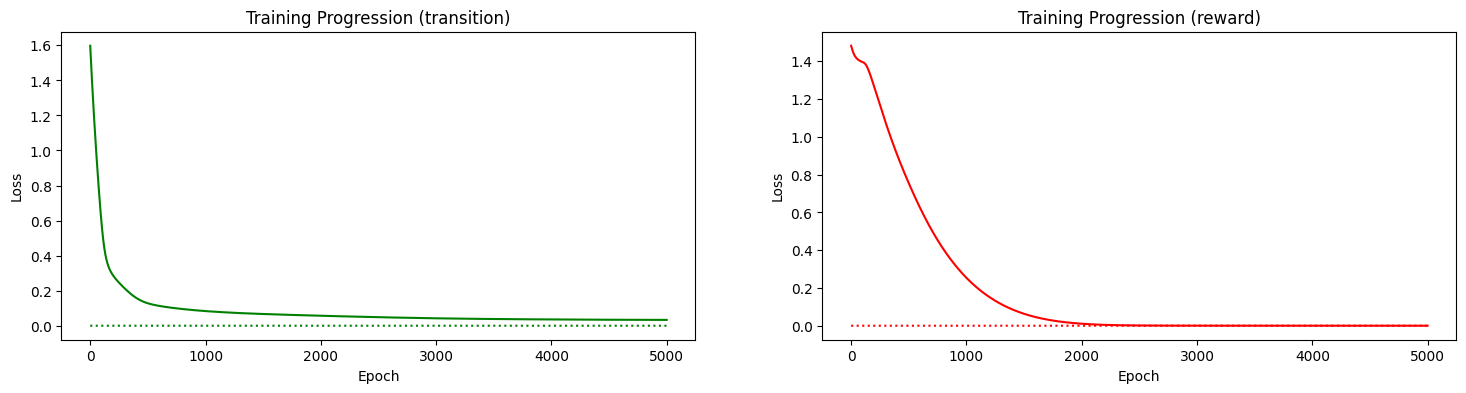

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

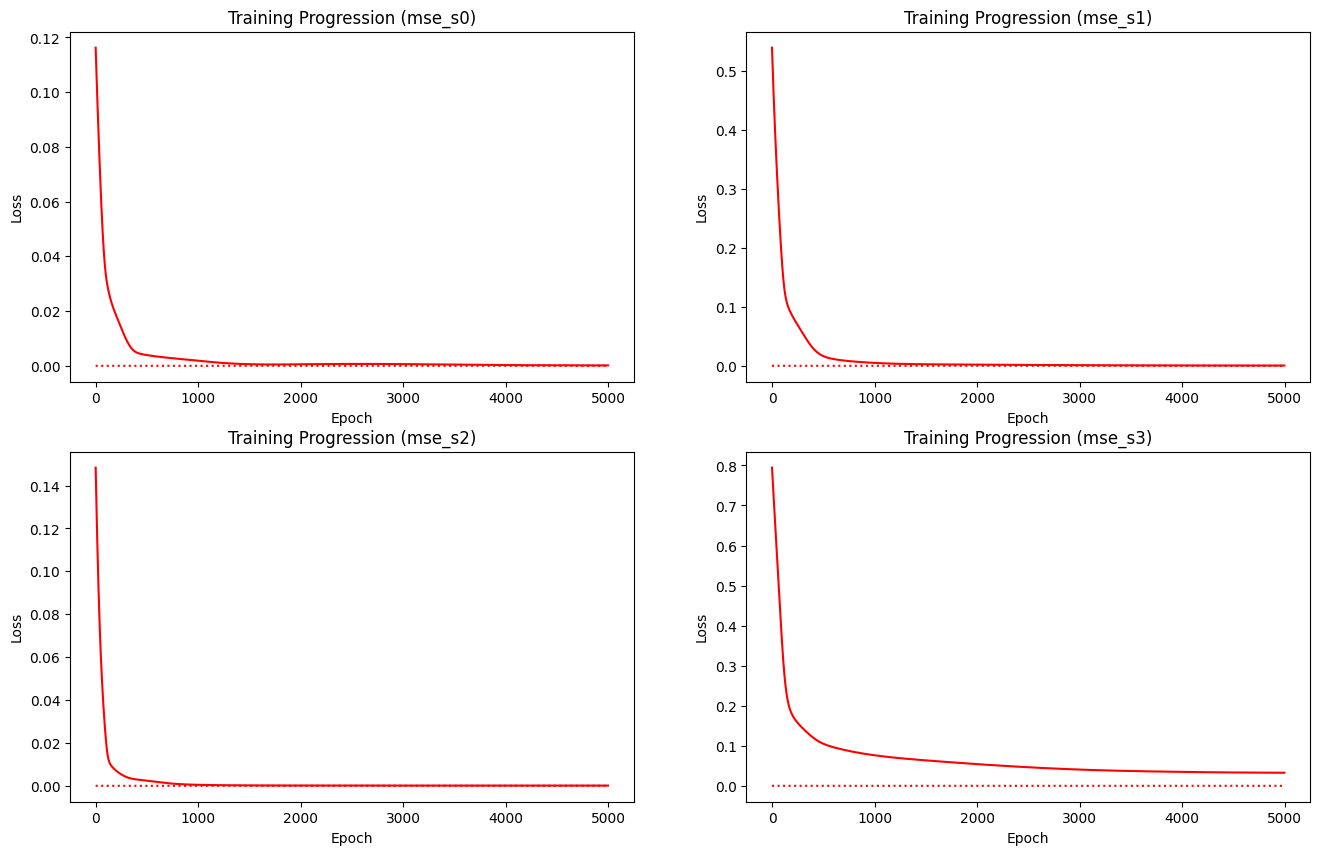

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

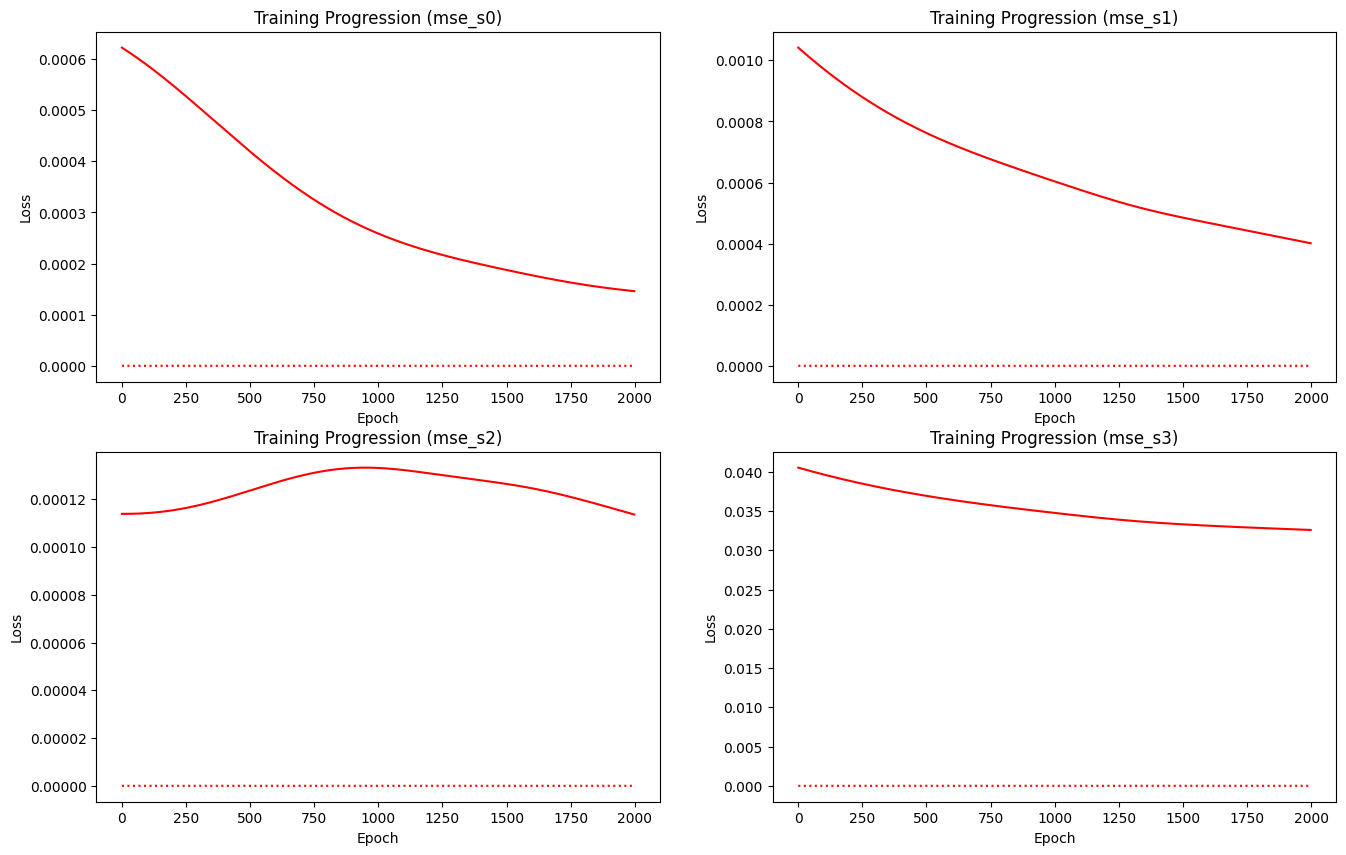

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data[train_data.epoch>3000].reset_index(drop=True), expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [8]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics(p=False)
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
0,0,0,"(0.5280280669895349, 0.1691488904272192)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.285, 0.013, 1.258)",0.0,1.0,"(-0.025, -0.525, 0.038, 2.534)",...,0.043,0.001,0.713,0.0,0.142857,0.151408,0.018182,0.368666,0.776,0.381540
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)",...,0.035,0.003,0.338,0.0,0.142857,0.123239,0.054545,0.174767,0.395,0.193485
2,2,0,"(0.5280280669895349, 0.1691488904272192)","(-0.025, -0.525, 0.038, 2.534)",1,1.0,"(-0.035, -0.288, 0.088, 1.326)",0.0,1.0,"(-0.041, -0.532, 0.115, 2.694)",...,0.046,0.007,0.894,0.0,0.142857,0.161972,0.127273,0.462254,0.966,0.475321
3,3,0,"(0.5280280669895349, 0.1691488904272192)","(-0.035, -0.288, 0.088, 1.326)",0,1.0,"(-0.041, -0.532, 0.115, 2.694)",1.0,1.0,"(-0.052, -0.3, 0.169, 1.601)",...,0.047,0.011,0.295,0.0,0.157895,0.165493,0.200000,0.152534,0.374,0.183119
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,0.045,0.013,0.969,0.0,0.142857,0.158451,0.236364,0.501034,1.046,0.514808


In [ ]:
results[['rse_s0','rse_s1','rse_s2','rse_s3','rse_r','rse_s0_normalized','rse_s1_normalized','rse_s2_normalized','rse_s3_normalized', 'rse']].describe()

,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.0,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.007511,0.011848,0.006071,0.130952,0.0,0.056471,0.041717,0.110373,0.067710,0.156381,0.075706
std,0.009674,0.015708,0.007017,0.162218,0.0,0.072737,0.055308,0.127576,0.083877,0.173705,0.085738
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.003000,0.000000
25%,0.002000,0.004000,0.002000,0.040000,0.0,0.015038,0.014085,0.036364,0.020683,0.061000,0.028628
50%,0.005000,0.008000,0.004000,0.081000,0.0,0.037594,0.028169,0.072727,0.041882,0.104000,0.049852
75%,0.009000,0.015000,0.008000,0.166000,0.0,0.067669,0.052817,0.145455,0.085832,0.190500,0.092547
max,0.133000,0.284000,0.055000,1.934000,0.0,1.000000,1.000000,1.000000,1.000000,2.029000,1.000000


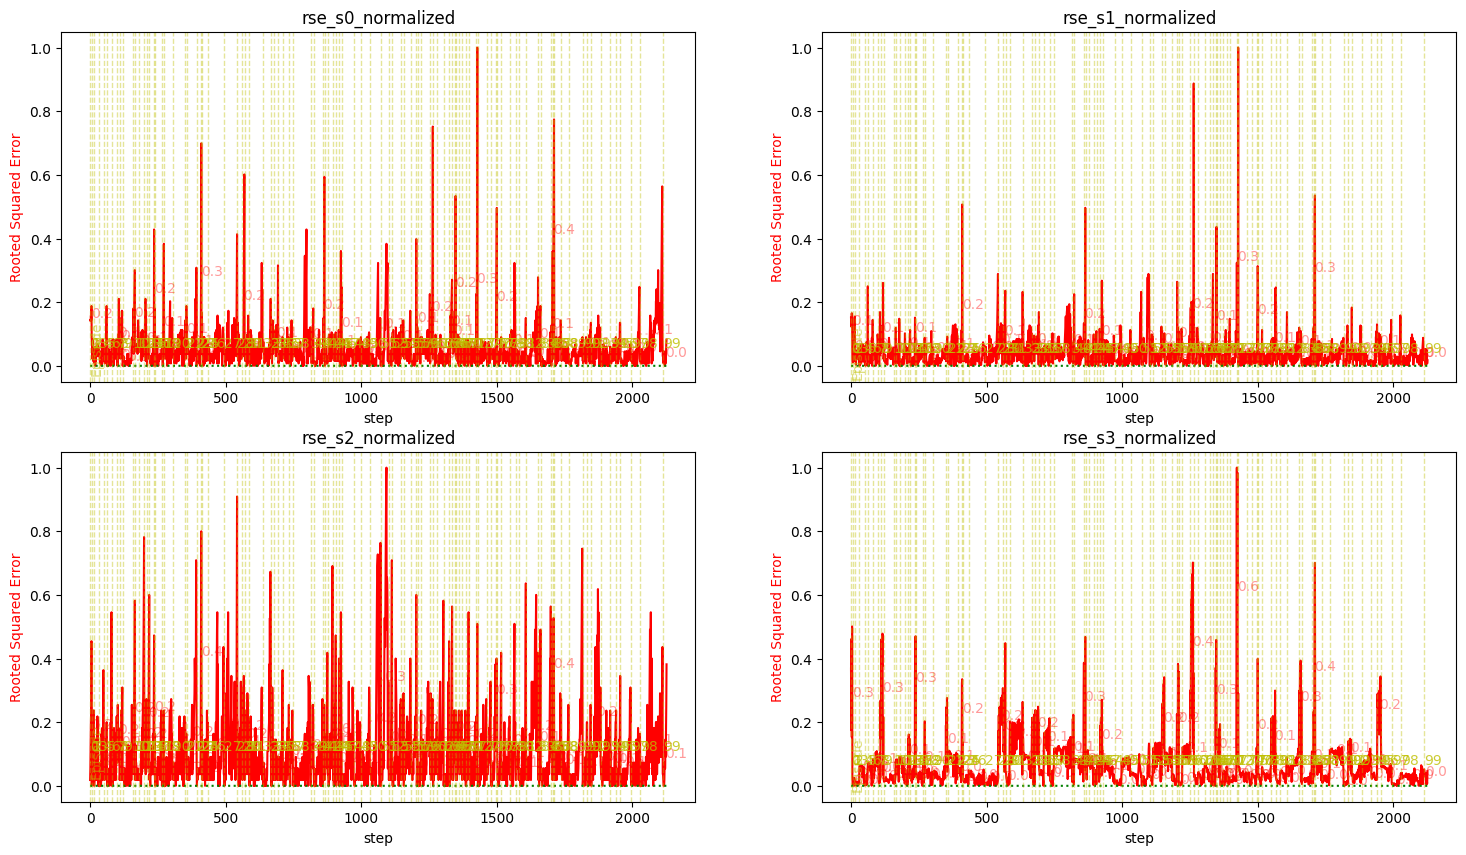

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3_normalized')

plt.show()

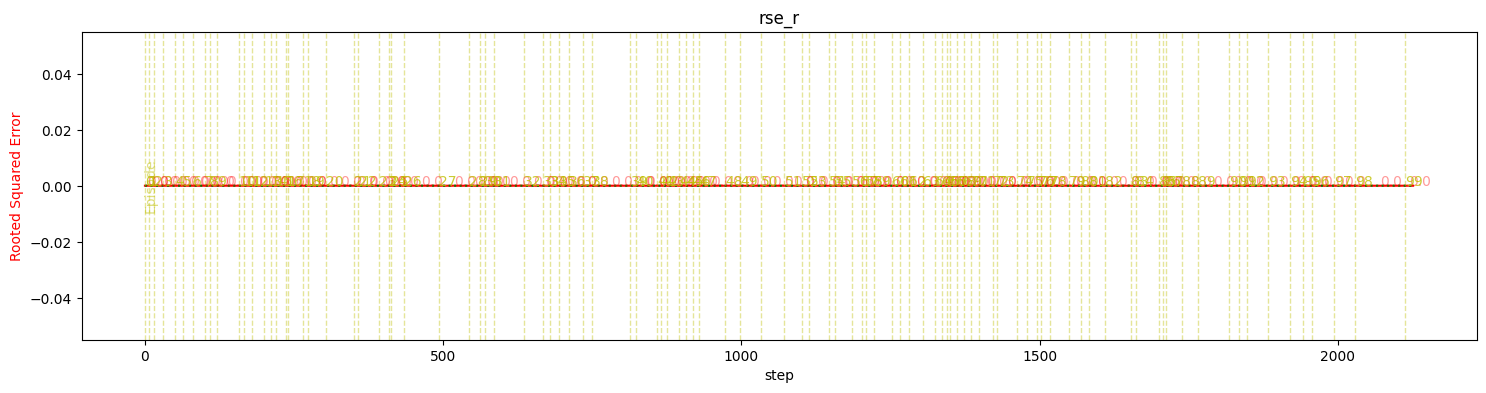

In [11]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

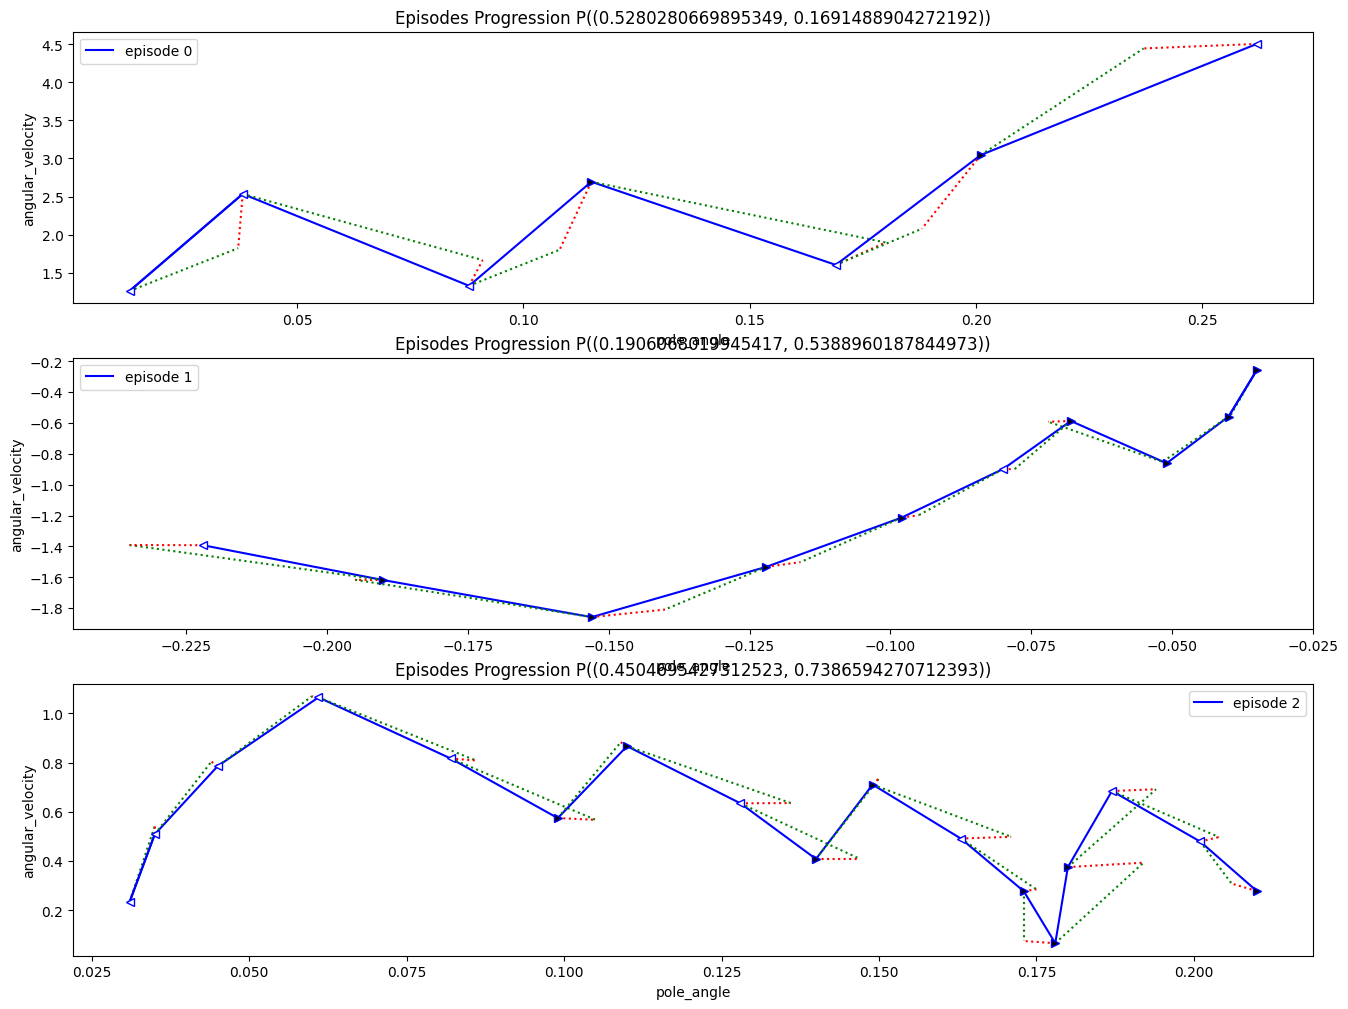

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()